In [140]:
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [123]:
# Download latest version
path = kagglehub.dataset_download("subhaditya/fer2013plus")

print("Path to dataset files:", path)

Path to dataset files: /home/omarhammad/.cache/kagglehub/datasets/subhaditya/fer2013plus/versions/1


In [124]:

data_transforms = {
    "train": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomCrop(48, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    "test": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
}

# Paths to dataset
train_dir = path + "/fer2013plus/fer2013/train"
test_dir = path + "/fer2013plus/fer2013/test"

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms["train"])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms["test"])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

print("Train loader and test loader created!")

# Check a sample batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)

# Get class-to-label mapping
class_names = train_dataset.classes
print("Class Names:", class_names)

# Example: label 0 corresponds to the first class
print("Label 0 is:", class_names[0])



Train loader and test loader created!
Image batch shape: torch.Size([16, 1, 48, 48])
Labels batch shape: torch.Size([16])
Labels: tensor([0, 5, 0, 7, 0, 0, 5, 5, 4, 5, 0, 5, 5, 5, 7, 4])
Class Names: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Label 0 is: anger


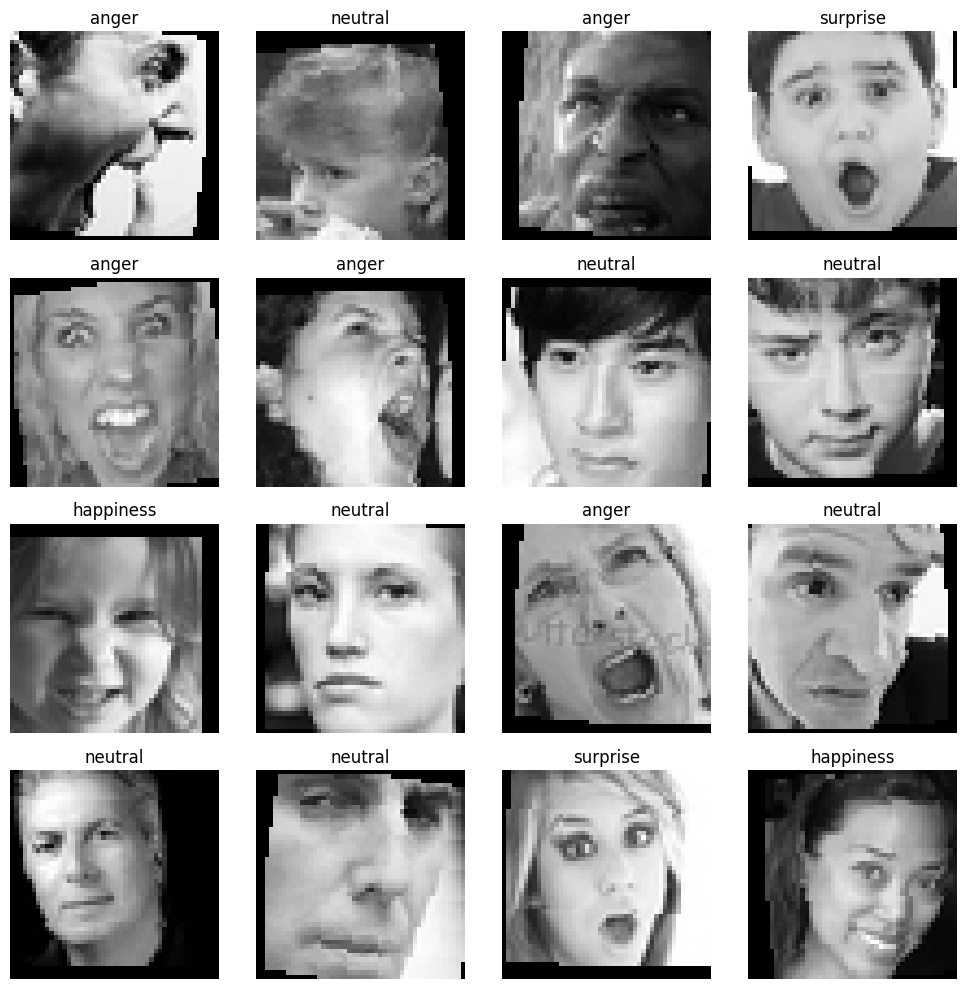

In [125]:
def plot_image_batch(images, labels, class_names):
    """
    Plots a batch of images with their corresponding labels.

    Args:
        images (Tensor): A batch of images (shape: [batch_size, channels, height, width]).
        labels (Tensor): Corresponding labels for the images.
        class_names (list): List of class names corresponding to the labels.
    """

    images = images.permute(0, 2, 3, 1).numpy()

    images = images * 0.5 + 0.5

    batch_size = images.shape[0]
    grid_size = int(batch_size ** 0.5)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        if i < batch_size:

            ax.imshow(images[i].squeeze(), cmap="gray" if images[i].shape[-1] == 1 else None)

            ax.set_title(class_names[labels[i]])
            ax.axis("off")
        else:

            ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_image_batch(images, labels, class_names)


In [126]:

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(in_features=128 * 6 * 6, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=8)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = CNN()

In [127]:

# Step 4: Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # call optimizer

In [128]:
# Step 5: Train the Model
num_epochs = 2  # define number of epochs
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i + 1) % 100 == 0:  # Print every 100 batches
            print(
                f"Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {running_loss / 100:.4f}")
            running_loss = 0.0

Epoch [1/2], Step [100/1775], Loss: 1.6225
Epoch [1/2], Step [200/1775], Loss: 1.6145
Epoch [1/2], Step [300/1775], Loss: 1.5448
Epoch [1/2], Step [400/1775], Loss: 1.5141
Epoch [1/2], Step [500/1775], Loss: 1.5244
Epoch [1/2], Step [600/1775], Loss: 1.4516
Epoch [1/2], Step [700/1775], Loss: 1.4046
Epoch [1/2], Step [800/1775], Loss: 1.4213
Epoch [1/2], Step [900/1775], Loss: 1.4087
Epoch [1/2], Step [1000/1775], Loss: 1.3691
Epoch [1/2], Step [1100/1775], Loss: 1.2993
Epoch [1/2], Step [1200/1775], Loss: 1.2887
Epoch [1/2], Step [1300/1775], Loss: 1.2711
Epoch [1/2], Step [1400/1775], Loss: 1.2415
Epoch [1/2], Step [1500/1775], Loss: 1.2899
Epoch [1/2], Step [1600/1775], Loss: 1.2033
Epoch [1/2], Step [1700/1775], Loss: 1.2181
Epoch [2/2], Step [100/1775], Loss: 1.1837
Epoch [2/2], Step [200/1775], Loss: 1.1186
Epoch [2/2], Step [300/1775], Loss: 1.1165
Epoch [2/2], Step [400/1775], Loss: 1.1223
Epoch [2/2], Step [500/1775], Loss: 1.1185
Epoch [2/2], Step [600/1775], Loss: 1.1096
Epo

In [129]:

# Step 6: Evaluate the Model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {correct / total:.4f}")

Test Accuracy: 0.6598


In [130]:
torch.save(model.state_dict(), 'cnn_model.pth')

In [131]:
# Prepare to count predictions for each class
classes = train_dataset.classes  # Get class names from the dataset
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# Disable gradients for evaluation
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)  # Get predicted class indices

        # Collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            label_name = classes[label]  # Convert label index to class name
            if label == prediction:
                correct_pred[label_name] += 1
            total_pred[label_name] += 1

# Print accuracy for each class
for classname, correct_count in correct_pred.items():
    if total_pred[classname] > 0:  # Avoid division by zero
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:10s} is {accuracy:.1f} %')
    else:
        print(f'No predictions for class: {classname}')


Accuracy for class: anger      is 36.2 %
Accuracy for class: contempt   is 0.0 %
Accuracy for class: disgust    is 0.0 %
Accuracy for class: fear       is 2.4 %
Accuracy for class: happiness  is 85.2 %
Accuracy for class: neutral    is 84.0 %
Accuracy for class: sadness    is 8.1 %
Accuracy for class: surprise   is 71.1 %


In [132]:
loaded_model = CNN()
loaded_model.load_state_dict(torch.load("cnn_model.pth", weights_only=True))

<All keys matched successfully>

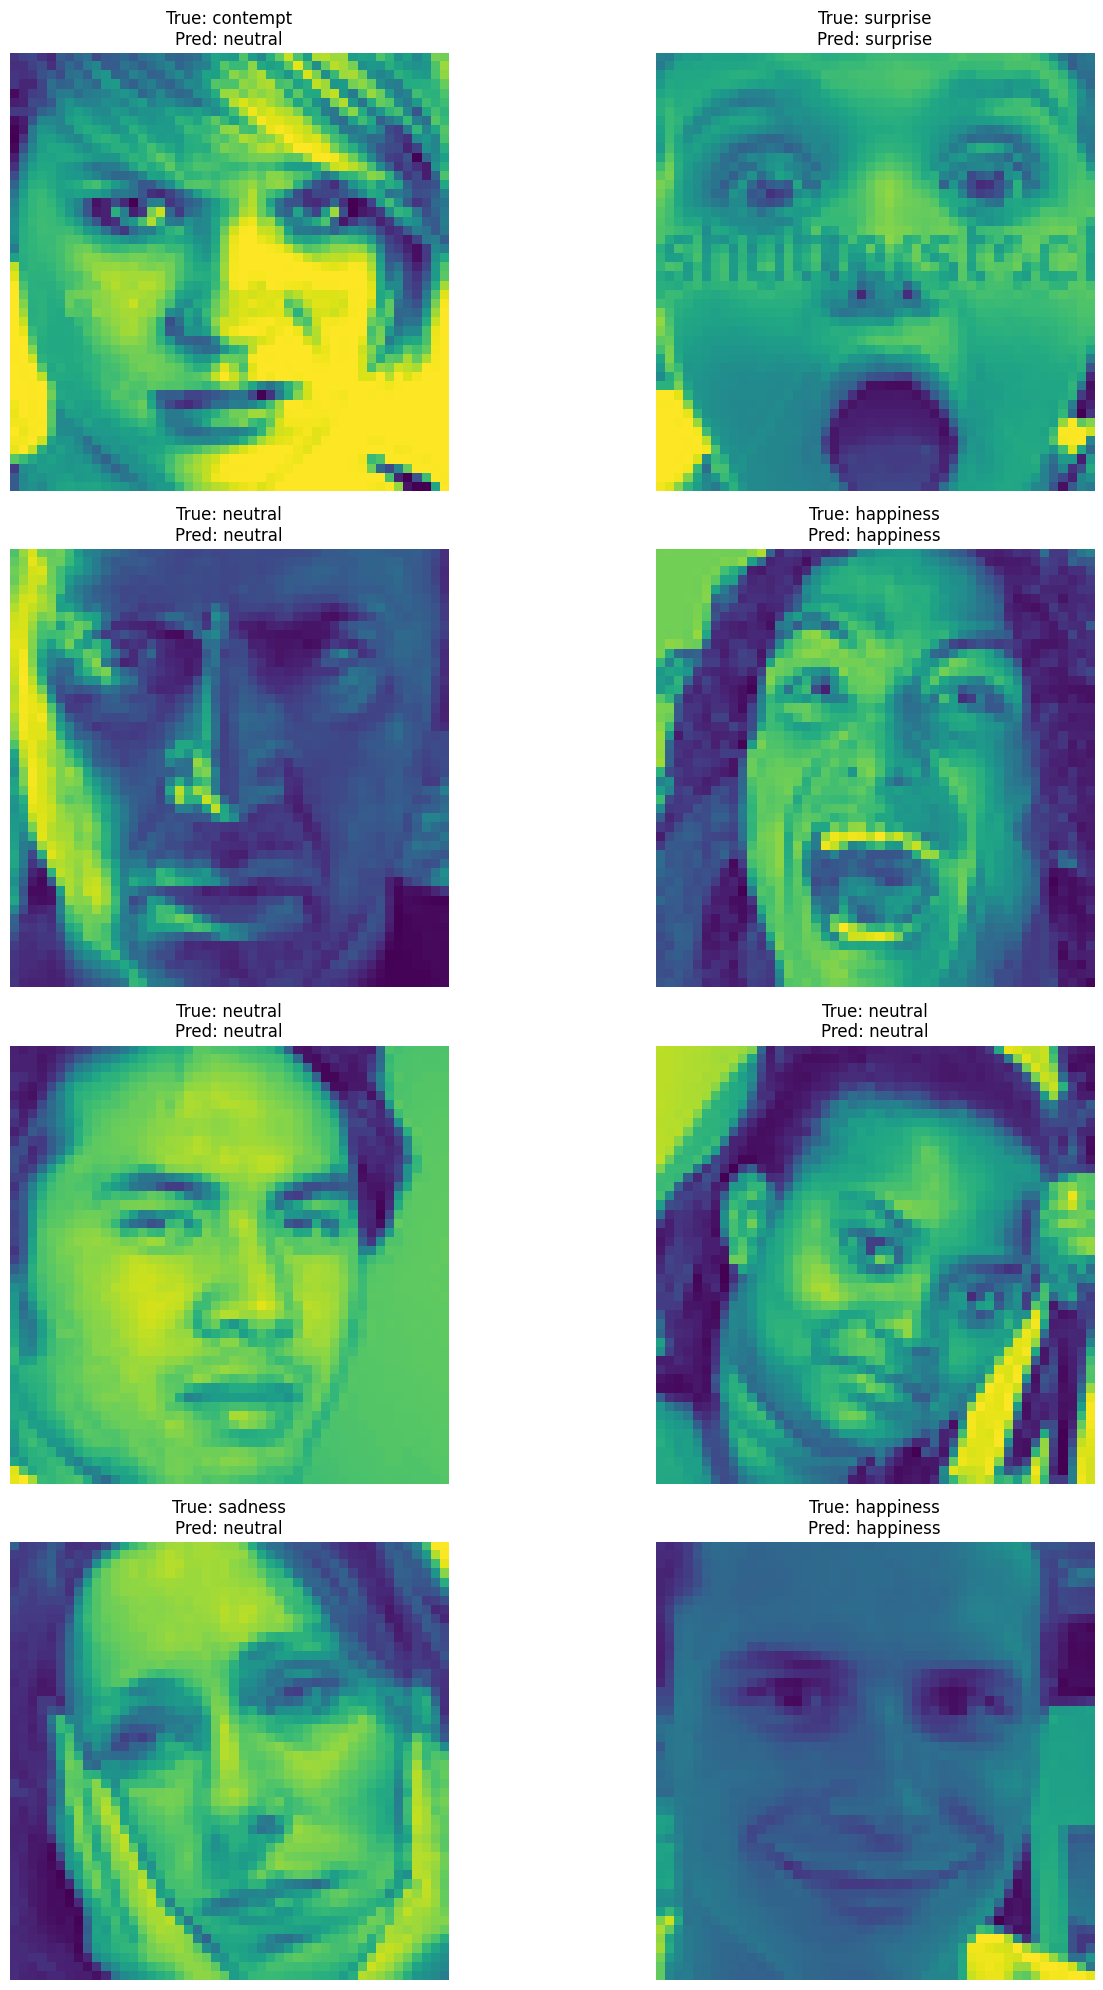

In [138]:
# Function to visualize original images with ground truth and predicted labels
def visualize_predictions_with_original_images(images, labels, predictions, classes):
    num_images = len(images)
    rows = (num_images + 1) // 2  # Number of rows for layout
    cols = 2  # Fixed number of columns

    plt.figure(figsize=(15, rows * 5))  # Adjust figure size
    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)

        # Convert tensor to numpy array for display
        img = images[i].permute(1, 2, 0).numpy()  # Rearrange dimensions for matplotlib

        plt.imshow(img)  # Display the original image

        # Add ground truth and predicted labels
        true_label = classes[labels[i]]
        pred_label = classes[predictions[i]]
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=12)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# Get a random batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Get predictions from the model
outputs = loaded_model(images)
_, predicted = torch.max(outputs, 1)

# Visualize the images with ground truth and predicted labels
visualize_predictions_with_original_images(images[:8], labels[:8], predicted[:8], classes)


In [145]:
import optuna
from torch.optim import Adam
from torch.utils.data import DataLoader
import torch.nn.functional as F

def objective(trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    dropout_rate = trial.suggest_uniform("dropout_rate", 0.2, 0.5)

    # Update data loaders with the suggested batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Modify the CNN with dropout
    class CNNWithDropout(CNN):
        def __init__(self):
            super(CNNWithDropout, self).__init__()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = self.pool(F.relu(self.conv3(x)))
            x = x.view(-1, 128 * 6 * 6)
            x = F.relu(self.dropout(self.fc1(x)))
            x = self.fc2(x)
            return x

    model = CNNWithDropout().to("cuda" if torch.cuda.is_available() else "cpu")
    optimizer = Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # Training loop
    model.train()
    for epoch in range(3):  # Use a small number of epochs for quick optimization
        for images, labels in train_loader:
            images, labels = images.to("cuda"), labels.to("cuda")
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to("cuda"), labels.to("cuda")
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return 1.0 - accuracy  # Minimize error (1 - accuracy)

# Run the optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

# Best hyperparameters
print("Best hyperparameters:", study.best_params)


[I 2024-11-30 17:56:25,416] A new study created in memory with name: no-name-f2a8be61-6bf7-41da-b8db-f8d148555762
/tmp/ipykernel_38047/2219855403.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
/tmp/ipykernel_38047/2219855403.py:10: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform("dropout_rate", 0.2, 0.5)
[W 2024-11-30 17:56:25,437] Trial 0 failed with parameters: {'learning_rate': 0.006661809025114453, 'batch_size': 32, 'dropout_rate': 0.3743376490418673} because of the following error: RuntimeError('CUDA error: CUDA-capable device(s) is/are busy or unavailable\nCUDA kernel error

RuntimeError: CUDA error: CUDA-capable device(s) is/are busy or unavailable
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
